# Project B — News Source Classification
**Fox News vs NBC News headline classification**

Binary text classification on ~3,800 scraped headlines.
Models progress from a course baseline (~66%) through classical ML ensembles,
a stacking meta-learner, and GPU-accelerated transformers.


In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib scipy
!pip install -q "xgboost>=2.2"
!pip install -q transformers datasets accelerate tf-keras
!pip install -q bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.8 MB/s eta 0:00:00


## 0. Setup

Run the pip install cell, then mount Google Drive (Colab) or skip (local).


In [2]:
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/5190finalproj')
    print('Working directory:', os.getcwd())
except Exception:
    print('Running locally.')

Mounted at /content/drive
Working directory: /content/drive/MyDrive/5190finalproj


## 1. Imports


In [3]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    roc_auc_score, confusion_matrix, classification_report
)
from scipy.optimize import minimize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_style('whitegrid')

PROJECT_ROOT = Path('.').resolve()
DATA_DIR     = PROJECT_ROOT / 'data'
FIG_DIR      = PROJECT_ROOT / 'figures'
MODEL_DIR    = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

CLEANED_CSV = DATA_DIR / 'cleaned.csv'
TRAIN_CSV   = DATA_DIR / 'train.csv'
VAL_CSV     = DATA_DIR / 'val.csv'
TEST_CSV    = DATA_DIR / 'test.csv'

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Project root:', PROJECT_ROOT)

Project root: /content/drive/MyDrive/5190finalproj


## 2. Load Data


In [4]:
df = pd.read_csv(CLEANED_CSV)
print(f'Total rows : {len(df)}')
print(f'Columns    : {list(df.columns)}')
print(f'Fox rate   : {df["label"].mean():.3f}  ({df["source"].value_counts().to_dict()})')
df[['source', 'headline_clean', 'headline_norm', 'label']].head(3)

Total rows : 3782
Columns    : ['url', 'source', 'headline', 'status', 'error', 'headline_clean', 'headline_norm', 'label']
Fox rate   : 0.529  ({'FoxNews': 2000, 'NBC': 1782})


,source,headline_clean,headline_norm,label
0,FoxNews,Lori Loughlin's husband Mossimo Giannulli asks...,lori loughlins husband mossimo giannulli asks ...,1
1,FoxNews,Back on the trail: Top Biden surrogate Newsom ...,back trail top biden surrogate newsom campaign...,1
2,FoxNews,Harris claims Trump abortion platform makes 'n...,harris claim trump abortion platform make exce...,1


## 3. Train / Val / Test Split

Stratified 70 / 15 / 15 — written to disk once so every notebook uses identical subsets.


In [5]:
if TRAIN_CSV.exists() and VAL_CSV.exists() and TEST_CSV.exists():
    train_df = pd.read_csv(TRAIN_CSV)
    val_df   = pd.read_csv(VAL_CSV)
    test_df  = pd.read_csv(TEST_CSV)
    print('Loaded splits from disk.')
else:
    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df['label'], random_state=SEED)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)
    train_df.to_csv(TRAIN_CSV, index=False)
    val_df.to_csv(VAL_CSV,   index=False)
    test_df.to_csv(TEST_CSV,  index=False)
    print('Created and saved splits.')

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# headline_clean for the course baseline reproduction
X_train = train_df['headline_clean']
y_train = train_df['label']
X_val   = val_df['headline_clean']
y_val   = val_df['label']
X_test  = test_df['headline_clean']
y_test  = test_df['label']

# headline_norm for all classical TF-IDF models
X_train_norm = train_df['headline_norm']
X_val_norm   = val_df['headline_norm']
X_test_norm  = test_df['headline_norm']

Loaded splits from disk.
Train: 2647 | Val: 567 | Test: 568


## 4. Evaluation Helper

Reports accuracy, macro-F1, MCC, ROC-AUC and saves a confusion-matrix figure.
All val results accumulate in `results` for the comparison table in Section 16.


In [6]:
results = []

def evaluate(name, model, X, y, split='val'):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y, y_pred)
    f1  = f1_score(y, y_pred, average='macro')
    mcc = matthews_corrcoef(y, y_pred)
    auc = roc_auc_score(y, y_prob) if y_prob is not None else float('nan')

    sep = '=' * 52
    print(sep)
    print(f'  {name}  [{split}]')
    print(sep)
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Macro-F1 : {f1:.4f}')
    print(f'  MCC      : {mcc:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(classification_report(y, y_pred, target_names=['NBC', 'FoxNews']))

    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NBC', 'FoxNews'],
                yticklabels=['NBC', 'FoxNews'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)
    plt.tight_layout()
    safe = name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(FIG_DIR / f'cm_{safe}.png', dpi=120)
    plt.show()

    results.append({'model': name, 'split': split,
                    'accuracy': acc, 'macro_f1': f1, 'mcc': mcc, 'roc_auc': auc})
    return acc, f1, mcc, auc

## 5. Course Baseline

TF-IDF (100 features) + Logistic Regression — exact setup from the project description.
**Target ≈ 66.49%.** All subsequent models must beat this.


  Course Baseline  [val]
  Accuracy : 0.7972
  Macro-F1 : 0.7947
  MCC      : 0.5937
  ROC-AUC  : 0.8732
              precision    recall  f1-score   support

         NBC       0.82      0.73      0.77       267
     FoxNews       0.78      0.86      0.82       300

    accuracy                           0.80       567
   macro avg       0.80      0.79      0.79       567
weighted avg       0.80      0.80      0.80       567



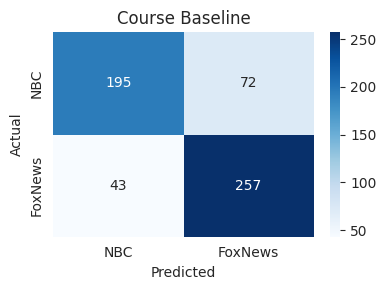

(0.7971781305114638,
 0.7947236695052653,
 np.float64(0.5937049949859635),
 np.float64(0.873183520599251))

In [7]:
baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english', max_features=5_000, ngram_range=(1, 2)
    )),
    ('clf', LogisticRegression(max_iter=500, C=1.0, random_state=SEED)),
])
baseline.fit(X_train, y_train)
evaluate('Course Baseline', baseline, X_val, y_val)

## 6. Logistic Regression

Word tri-grams + char (2–6) n-grams via `FeatureUnion`.
Grid searches over **L2** (lbfgs) and **elastic-net** (saga) regularisation,
and over both `headline_clean` and `headline_norm` text columns.
The winning combination is kept as `improved_lr`.


LR headline_clean        {'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}  CV F1=0.8186
LR headline_norm         {'clf__C': 1.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}  CV F1=0.7995

Best LR text column: headline_clean
  Logistic Regression  [val]
  Accuracy : 0.8307
  Macro-F1 : 0.8300
  MCC      : 0.6600
  ROC-AUC  : 0.9109
              precision    recall  f1-score   support

         NBC       0.83      0.81      0.82       267
     FoxNews       0.84      0.85      0.84       300

    accuracy                           0.83       567
   macro avg       0.83      0.83      0.83       567
weighted avg       0.83      0.83      0.83       567



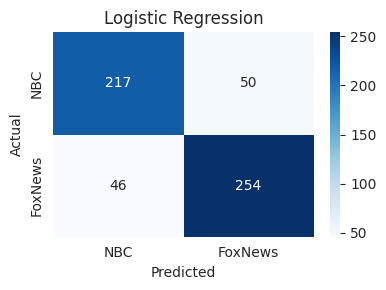

In [8]:
# word(1-3) + char_wb(2-6), full vocab, elastic-net AND L2, both text columns.
def make_lr_pipe(lowercase=False):
    return Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 3),
                max_features=None, sublinear_tf=True, min_df=2,
                lowercase=lowercase,
            )),
            ('char', TfidfVectorizer(
                analyzer='char_wb', ngram_range=(2, 6),
                max_features=50_000, sublinear_tf=True, min_df=3,
                lowercase=lowercase,
            )),
        ])),
        ('clf', LogisticRegression(
            max_iter=2000, class_weight='balanced', random_state=SEED,
        )),
    ])

param_grid_lr = [
    {'clf__C': [0.5, 1.0, 2.0, 5.0, 10.0],
     'clf__penalty': ['l2'], 'clf__solver': ['lbfgs']},
    {'clf__C': [0.5, 1.0, 2.0, 5.0],
     'clf__penalty': ['elasticnet'], 'clf__solver': ['saga'],
     'clf__l1_ratio': [0.15, 0.5, 0.85]},
]

lr_X_train, lr_X_val = X_train, X_val   # defaults; updated below if norm wins
_best_lr_score, improved_lr = -1, None

for text_col, X_tr, X_v in [
    ('headline_clean', X_train,      X_val),
    ('headline_norm',  X_train_norm, X_val_norm),
]:
    gs = GridSearchCV(
        make_lr_pipe(lowercase=(text_col == 'headline_norm')),
        param_grid_lr, cv=SKF, scoring='f1_macro', n_jobs=-1, verbose=0,
    )
    gs.fit(X_tr, y_train)
    print(f'LR {text_col:20s}  {gs.best_params_}  CV F1={gs.best_score_:.4f}')
    if gs.best_score_ > _best_lr_score:
        _best_lr_score, improved_lr = gs.best_score_, gs.best_estimator_
        lr_X_train, lr_X_val = X_tr, X_v

print(f'\nBest LR text column: {"headline_norm" if lr_X_val is X_val_norm else "headline_clean"}')
evaluate('Logistic Regression', improved_lr, lr_X_val, y_val)

lr_X_test  = X_test if lr_X_val  is X_val else X_test_norm


## 7. Naive Bayes

`ComplementNB` with **word tri-grams + char (2–5) n-grams** via `FeatureUnion`.
Grid searches over alpha (0.001 → 2.0) and `norm`, and over both text columns.


NB headline_clean        alpha=0.05      norm=False   CV F1=0.8274
NB headline_norm         alpha=0.1       norm=False   CV F1=0.7919

Best NB text column: headline_clean
  Naive Bayes  [val]
  Accuracy : 0.8219
  Macro-F1 : 0.8206
  MCC      : 0.6423
  ROC-AUC  : 0.8858
              precision    recall  f1-score   support

         NBC       0.83      0.78      0.81       267
     FoxNews       0.82      0.86      0.84       300

    accuracy                           0.82       567
   macro avg       0.82      0.82      0.82       567
weighted avg       0.82      0.82      0.82       567



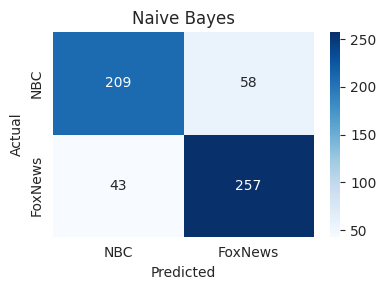

In [9]:
# word(1-3) + char_wb(2-5) counts, wider alpha grid, both columns.
def make_nb_pipe(lowercase=False):
    return Pipeline([
        ('features', FeatureUnion([
            ('word', CountVectorizer(
                analyzer='word', ngram_range=(1, 3),
                max_features=100_000, min_df=2, lowercase=lowercase,
            )),
            ('char', CountVectorizer(
                analyzer='char_wb', ngram_range=(2, 5),
                max_features=50_000, min_df=2, lowercase=lowercase,
            )),
        ])),
        ('clf', ComplementNB()),
    ])

param_grid_nb = {
    'clf__alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
    'clf__norm':  [True, False],
}

nb_X_train, nb_X_val = X_train_norm, X_val_norm  # defaults
_best_nb_score, nb = -1, None

for text_col, X_tr, X_v in [
    ('headline_clean', X_train,      X_val),
    ('headline_norm',  X_train_norm, X_val_norm),
]:
    gs = GridSearchCV(
        make_nb_pipe(lowercase=(text_col == 'headline_norm')),
        param_grid_nb, cv=SKF, scoring='f1_macro', n_jobs=-1, verbose=0,
    )
    gs.fit(X_tr, y_train)
    print(f'NB {text_col:20s}  alpha={gs.best_params_["clf__alpha"]:<8}  '
          f'norm={str(gs.best_params_["clf__norm"]):<6}  CV F1={gs.best_score_:.4f}')
    if gs.best_score_ > _best_nb_score:
        _best_nb_score, nb = gs.best_score_, gs.best_estimator_
        nb_X_train, nb_X_val = X_tr, X_v

print(f'\nBest NB text column: {"headline_norm" if nb_X_val is X_val_norm else "headline_clean"}')
evaluate('Naive Bayes', nb, nb_X_val, y_val)

nb_X_test  = X_test if nb_X_val  is X_val else X_test_norm


## 8. Support Vector Machine

`LinearSVC` with word (1–3) + char (2–6) TF-IDF features, an **L2 Normalizer**,
and a two-dimensional grid over `C` and `loss` function.
`CalibratedClassifierCV` (cv=5) adds Platt-scaled probabilities for the ensemble.


SVM headline_clean        C=1.0     loss=hinge             CV F1=0.8281
SVM headline_norm         C=1.0     loss=squared_hinge     CV F1=0.8021

Best SVM params: {'clf__C': 1.0, 'clf__loss': 'hinge'}
  SVM  [val]
  Accuracy : 0.8360
  Macro-F1 : 0.8352
  MCC      : 0.6706
  ROC-AUC  : 0.9090
              precision    recall  f1-score   support

         NBC       0.83      0.81      0.82       267
     FoxNews       0.84      0.86      0.85       300

    accuracy                           0.84       567
   macro avg       0.84      0.83      0.84       567
weighted avg       0.84      0.84      0.84       567



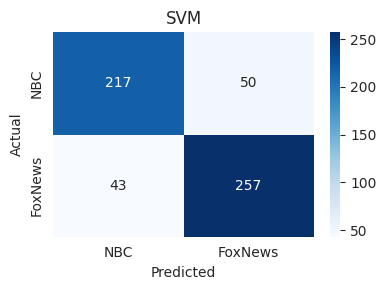

In [10]:
# word(1-3) + char_wb(2-6) TF-IDF, L2 Normalizer, C + loss grid, both columns.
from sklearn.preprocessing import Normalizer

def make_svm_pipe(lowercase=False):
    return Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 3),
                max_features=100_000, sublinear_tf=True, min_df=2,
                lowercase=lowercase,
            )),
            ('char', TfidfVectorizer(
                analyzer='char_wb', ngram_range=(2, 6),
                max_features=50_000, sublinear_tf=True, min_df=2,
                lowercase=lowercase,
            )),
        ])),
        ('norm', Normalizer(norm='l2')),
        ('clf', LinearSVC(class_weight='balanced', max_iter=3000, random_state=SEED)),
    ])

param_grid_svm = [
    {'clf__C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
     'clf__loss': ['hinge', 'squared_hinge']},
]

svm_X_train, svm_X_val = X_train, X_val   # defaults
_best_svm_score, _best_svm_params, _best_svm_lc = -1, None, False

for text_col, X_tr, X_v in [
    ('headline_clean', X_train,      X_val),
    ('headline_norm',  X_train_norm, X_val_norm),
]:
    gs = GridSearchCV(
        make_svm_pipe(lowercase=(text_col == 'headline_norm')),
        param_grid_svm, cv=SKF, scoring='f1_macro', n_jobs=-1, verbose=0,
    )
    gs.fit(X_tr, y_train)
    print(f'SVM {text_col:20s}  C={gs.best_params_["clf__C"]:<6}  '
          f'loss={gs.best_params_["clf__loss"]:<16}  CV F1={gs.best_score_:.4f}')
    if gs.best_score_ > _best_svm_score:
        _best_svm_score  = gs.best_score_
        _best_svm_params = gs.best_params_
        _best_svm_lc     = (text_col == 'headline_norm')
        svm_X_train, svm_X_val = X_tr, X_v

print(f'\nBest SVM params: {_best_svm_params}')
svm = Pipeline([
    ('features', FeatureUnion([
        ('word', TfidfVectorizer(
            analyzer='word', ngram_range=(1, 3),
            max_features=100_000, sublinear_tf=True, min_df=2,
            lowercase=_best_svm_lc,
        )),
        ('char', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(2, 6),
            max_features=50_000, sublinear_tf=True, min_df=2,
            lowercase=_best_svm_lc,
        )),
    ])),
    ('norm', Normalizer(norm='l2')),
    ('clf', CalibratedClassifierCV(
        LinearSVC(
            C=_best_svm_params['clf__C'],
            loss=_best_svm_params['clf__loss'],
            class_weight='balanced', max_iter=3000, random_state=SEED,
        ), cv=5,
    )),
])
svm.fit(svm_X_train, y_train)
evaluate('SVM', svm, svm_X_val, y_val)

svm_X_test = X_test if svm_X_val is X_val else X_test_norm


## 9. Random Forest

Word (1–2) + char (3–5) TF-IDF via `FeatureUnion`, 500 trees.
Grid searches over split `max_features` (log2 / sqrt / 0.15) and `min_samples_leaf`.


  Random Forest  [val]
  Accuracy : 0.7937
  Macro-F1 : 0.7922
  MCC      : 0.5854
  ROC-AUC  : 0.8533
              precision    recall  f1-score   support

         NBC       0.80      0.75      0.77       267
     FoxNews       0.79      0.83      0.81       300

    accuracy                           0.79       567
   macro avg       0.79      0.79      0.79       567
weighted avg       0.79      0.79      0.79       567



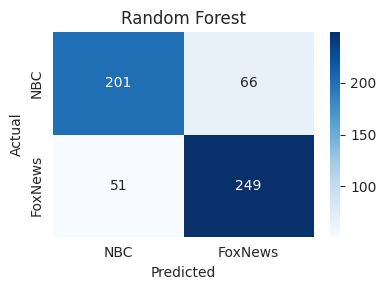

(0.7936507936507936,
 0.7921612857747075,
 np.float64(0.5854461469778719),
 np.float64(0.8532584269662922))

In [12]:
def make_rf_pipe(lowercase=True):
    return Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                analyzer='word',
                ngram_range=(1, 2),
                max_features=20_000,
                sublinear_tf=True,
                min_df=2,
                lowercase=lowercase,
            )),
            ('char', TfidfVectorizer(
                analyzer='char_wb',
                ngram_range=(3, 5),
                max_features=30_000,
                sublinear_tf=True,
                min_df=3,
                lowercase=lowercase,
            )),
        ])),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            max_features='sqrt',
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=SEED,
        )),
    ])

# Use normalized text only to avoid running the whole search twice
rf_X_train, rf_X_val, rf_X_test = X_train_norm, X_val_norm, X_test_norm

rf = make_rf_pipe(lowercase=True)
rf.fit(rf_X_train, y_train)

evaluate('Random Forest', rf, rf_X_val, y_val)

### Random Forest — Feature Importances

Top-20 tokens by mean impurity decrease (unsigned — high importance = separates classes).


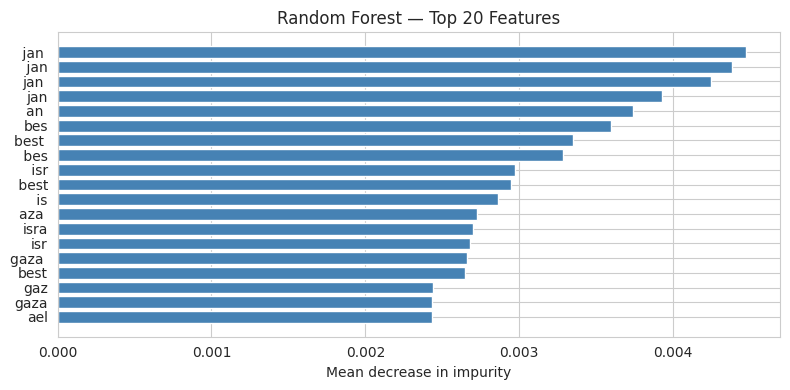

feature  importance
   jan     0.004470
    jan    0.004382
   jan     0.004247
    jan    0.003928
    jan    0.003761
    an     0.003740
    bes    0.003598
  best     0.003346
    bes    0.003285
    isr    0.002974
   best    0.002946
     is    0.002860
   aza     0.002722
   isra    0.002697
    isr    0.002678
  gaza     0.002662
   best    0.002649
    gaz    0.002441
   gaza    0.002436
    ael    0.002433


In [13]:
rf_fu     = rf.named_steps['features']
rf_word_f = rf_fu.transformer_list[0][1].get_feature_names_out()
rf_char_f = rf_fu.transformer_list[1][1].get_feature_names_out()
rf_feats  = list(rf_word_f) + list(rf_char_f)
rf_imp    = rf.named_steps['clf'].feature_importances_

imp_df = (pd.DataFrame({'feature': rf_feats, 'importance': rf_imp})
            .sort_values('importance', ascending=False)
            .reset_index(drop=True))

top20 = imp_df.head(20)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
ax.set_xlabel('Mean decrease in impurity')
ax.set_title('Random Forest — Top 20 Features')
plt.tight_layout()
plt.savefig(FIG_DIR / 'rf_importance.png', dpi=120)
plt.show()
print(top20[['feature', 'importance']].to_string(index=False))


## 10. XGBoost

50k-feature TF-IDF, `tree_method='hist'` for sparse matrices.
Expanded grid: `n_estimators`, `learning_rate`, `max_depth`, `min_child_weight`, `reg_alpha`.
`scale_pos_weight` handles the Fox/NBC class imbalance natively.


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best XGB params: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__min_child_weight': 1, 'clf__n_estimators': 350}
Best CV F1: 0.7121715375646906
  XGBoost  [val]
  Accuracy : 0.7354
  Macro-F1 : 0.7354
  MCC      : 0.4789
  ROC-AUC  : 0.8201
              precision    recall  f1-score   support

         NBC       0.69      0.80      0.74       267
     FoxNews       0.79      0.68      0.73       300

    accuracy                           0.74       567
   macro avg       0.74      0.74      0.74       567
weighted avg       0.74      0.74      0.74       567



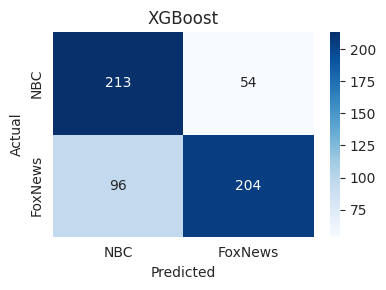

In [15]:
from xgboost import XGBClassifier

_pos_w = float((y_train == 0).sum()) / float((y_train == 1).sum())

xgb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        max_features=40_000,
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
        strip_accents='unicode',
        lowercase=False
    )),
    ('clf', XGBClassifier(
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=_pos_w,
        tree_method='hist',
        n_jobs=-1,
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0,
    )),
])

param_grid_xgb_fast = {
    'clf__n_estimators': [250, 350],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [4, 5],
    'clf__min_child_weight': [1, 3],
}

gs = GridSearchCV(
    xgb_pipe,
    param_grid_xgb_fast,
    cv=SKF,
    scoring='f1_macro',
    n_jobs=1,          # important: let XGBoost use all cores internally
    verbose=1,
)

gs.fit(X_train, y_train)

xgb_model = gs.best_estimator_

print('Best XGB params:', gs.best_params_)
print('Best CV F1:', gs.best_score_)

evaluate('XGBoost', xgb_model, X_val, y_val)

xgb_X_test = X_test

## 11. Soft Voting Ensemble

Nelder-Mead optimised weighted average of LR, SVM, NB, and XGBoost class-1 probabilities.
Each model contributes its val probabilities from whichever text column it was trained on.


Optimal weights — LR:0.250 SVM:0.250 NB:0.250 XGB:0.250
  Soft Voting Ensemble (optimized weights)  [val]
  Accuracy : 0.8377
  Macro-F1 : 0.8368
  MCC      : 0.6741
  ROC-AUC  : 0.9065
              precision    recall  f1-score   support

         NBC       0.84      0.81      0.82       267
     FoxNews       0.84      0.86      0.85       300

    accuracy                           0.84       567
   macro avg       0.84      0.84      0.84       567
weighted avg       0.84      0.84      0.84       567



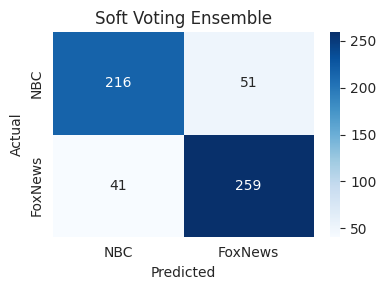

In [16]:
probs_lr  = improved_lr.predict_proba(lr_X_val)[:, 1]
probs_svm = svm.predict_proba(svm_X_val)[:, 1]
probs_nb  = nb.predict_proba(nb_X_val)[:, 1]
probs_xgb = xgb_model.predict_proba(xgb_X_val)[:, 1]
all_probs = np.stack([probs_lr, probs_svm, probs_nb, probs_xgb])

def neg_f1(w):
    total = np.abs(w).sum()
    if total == 0:
        return 0.0
    w_norm = np.abs(w) / total
    prob = np.dot(w_norm, all_probs)
    pred = (prob >= 0.5).astype(int)
    return -f1_score(y_val, pred, average='macro')

result  = minimize(neg_f1, x0=[1, 1, 1, 1], method='Nelder-Mead',
                   options={'maxiter': 2000})
best_w  = np.abs(result.x) / np.abs(result.x).sum()
print(f'Optimal weights — LR:{best_w[0]:.3f} SVM:{best_w[1]:.3f} '
      f'NB:{best_w[2]:.3f} XGB:{best_w[3]:.3f}')

ens_prob = np.dot(best_w, all_probs)
ens_pred = (ens_prob >= 0.5).astype(int)

acc = accuracy_score(y_val, ens_pred)
f1  = f1_score(y_val, ens_pred, average='macro')
mcc = matthews_corrcoef(y_val, ens_pred)
auc = roc_auc_score(y_val, ens_prob)

sep = '=' * 52
print(sep)
print('  Soft Voting Ensemble (optimized weights)  [val]')
print(sep)
print(f'  Accuracy : {acc:.4f}')
print(f'  Macro-F1 : {f1:.4f}')
print(f'  MCC      : {mcc:.4f}')
print(f'  ROC-AUC  : {auc:.4f}')
print(classification_report(y_val, ens_pred, target_names=['NBC', 'FoxNews']))

cm = confusion_matrix(y_val, ens_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NBC', 'FoxNews'],
            yticklabels=['NBC', 'FoxNews'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Soft Voting Ensemble')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cm_ensemble.png', dpi=120)
plt.show()

results.append({'model': 'Soft Voting Ensemble', 'split': 'val',
                'accuracy': acc, 'macro_f1': f1, 'mcc': mcc, 'roc_auc': auc})


## 12. Stacking Ensemble

Logistic regression meta-learner trained on **out-of-fold (OOF)** probabilities from all
four base models — OOF predictions are unbiased and prevent val-set leakage into the meta-learner.
Threshold-tuned on val for best macro-F1.


Generating OOF predictions...
OOF done.
  Stacking Ensemble (thresh=0.42)  [val]
  Accuracy : 0.8448
  Macro-F1 : 0.8436
  MCC      : 0.6886
  ROC-AUC  : 0.9118
              precision    recall  f1-score   support

         NBC       0.86      0.81      0.83       267
     FoxNews       0.84      0.88      0.86       300

    accuracy                           0.84       567
   macro avg       0.85      0.84      0.84       567
weighted avg       0.85      0.84      0.84       567



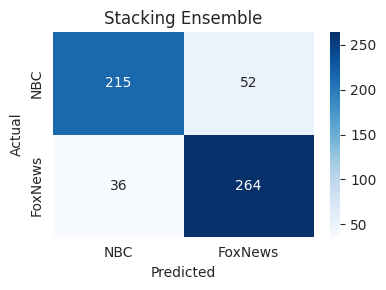

Meta-learner weights — LR:2.353 SVM:2.063 NB:1.071 XGB:0.577


In [17]:
from sklearn.model_selection import cross_val_predict

print('Generating OOF predictions...')
oof_lr  = cross_val_predict(improved_lr, lr_X_train,  y_train, cv=SKF, method='predict_proba', n_jobs=-1)[:, 1]
oof_svm = cross_val_predict(svm,         svm_X_train, y_train, cv=SKF, method='predict_proba', n_jobs=-1)[:, 1]
oof_nb  = cross_val_predict(nb,          nb_X_train,  y_train, cv=SKF, method='predict_proba', n_jobs=-1)[:, 1]
oof_xgb = cross_val_predict(xgb_model,   xgb_X_train, y_train, cv=SKF, method='predict_proba', n_jobs=1)[:, 1]
print('OOF done.')

X_meta_train = np.column_stack([oof_lr, oof_svm, oof_nb, oof_xgb])
X_meta_val   = np.column_stack([probs_lr, probs_svm, probs_nb, probs_xgb])

meta_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
meta_lr.fit(X_meta_train, y_train)

y_pred_stack = meta_lr.predict(X_meta_val)
y_prob_stack = meta_lr.predict_proba(X_meta_val)[:, 1]

best_thresh_s, best_f1_s = 0.5, 0.0
for t in np.arange(0.3, 0.71, 0.01):
    preds_t = (y_prob_stack >= t).astype(int)
    f1_t = f1_score(y_val, preds_t, average='macro')
    if f1_t > best_f1_s:
        best_f1_s, best_thresh_s = f1_t, t
y_pred_stack_tuned = (y_prob_stack >= best_thresh_s).astype(int)

acc = accuracy_score(y_val, y_pred_stack_tuned)
f1  = f1_score(y_val, y_pred_stack_tuned, average='macro')
mcc = matthews_corrcoef(y_val, y_pred_stack_tuned)
auc = roc_auc_score(y_val, y_prob_stack)

sep = '=' * 52
print(sep)
print(f'  Stacking Ensemble (thresh={best_thresh_s:.2f})  [val]')
print(sep)
print(f'  Accuracy : {acc:.4f}')
print(f'  Macro-F1 : {f1:.4f}')
print(f'  MCC      : {mcc:.4f}')
print(f'  ROC-AUC  : {auc:.4f}')
print(classification_report(y_val, y_pred_stack_tuned, target_names=['NBC', 'FoxNews']))

cm = confusion_matrix(y_val, y_pred_stack_tuned)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NBC', 'FoxNews'], yticklabels=['NBC', 'FoxNews'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Stacking Ensemble')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cm_stacking.png', dpi=120)
plt.show()

print(f'Meta-learner weights — LR:{meta_lr.coef_[0][0]:.3f} SVM:{meta_lr.coef_[0][1]:.3f} '
      f'NB:{meta_lr.coef_[0][2]:.3f} XGB:{meta_lr.coef_[0][3]:.3f}')

results.append({'model': 'Stacking Ensemble', 'split': 'val',
                'accuracy': acc, 'macro_f1': f1, 'mcc': mcc, 'roc_auc': auc})


## 13. RoBERTa-large Fine-tuning  *(GPU required)*

Full fine-tuning of `roberta-large` for binary sequence classification.
10 epochs with early stopping, linear warmup, label smoothing, and fp16.
Followed by a 3-seed ensemble for variance reduction.
Expected val accuracy: **90–96%**.


In [18]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback, set_seed as hf_set_seed
)
from datasets import Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cpu":
    print("WARNING: No GPU detected — skipping RoBERTa sections (CPU training not practical).")
else:
    ROBERTA_NAME = "roberta-large"
    ROBERTA_DIR  = MODEL_DIR / "roberta"

    tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)

    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

    rob_train_ds = Dataset.from_dict({"text": X_train.tolist(), "label": y_train.tolist()})
    rob_val_ds   = Dataset.from_dict({"text": X_val.tolist(),   "label": y_val.tolist()})

    rob_train_ds = rob_train_ds.map(tokenize_batch, batched=True)
    rob_val_ds   = rob_val_ds.map(tokenize_batch,   batched=True)

    rob_train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    rob_val_ds.set_format("torch",   columns=["input_ids", "attention_mask", "label"])

    print(f"Model : {ROBERTA_NAME}")
    print(f"Train : {len(rob_train_ds)} | Val: {len(rob_val_ds)}")


Device: cpu


In [19]:
if device == "cuda":
    hf_set_seed(SEED)
    roberta_model = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_NAME, num_labels=2)

    roberta_args = TrainingArguments(
        output_dir=str(ROBERTA_DIR),
        num_train_epochs=10,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=32,
        learning_rate=1e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        label_smoothing_factor=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        save_total_limit=1,
        fp16=True,
        seed=SEED,
        logging_steps=50,
        report_to="none",
    )

    roberta_trainer = Trainer(
        model=roberta_model,
        args=roberta_args,
        train_dataset=rob_train_ds,
        eval_dataset=rob_val_ds,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    roberta_trainer.train()
    print("Training complete.")
else:
    print("Skipped: RoBERTa training requires a GPU.")


Skipped: RoBERTa training requires a GPU.


In [20]:
if device == "cuda" and "roberta_trainer" in dir():
    rob_preds  = roberta_trainer.predict(rob_val_ds)
    y_pred_rob = rob_preds.predictions.argmax(-1)

    logits = rob_preds.predictions
    e_x = np.exp(logits - logits.max(axis=1, keepdims=True))
    y_prob_rob = (e_x / e_x.sum(axis=1, keepdims=True))[:, 1]

    acc = accuracy_score(y_val, y_pred_rob)
    f1  = f1_score(y_val, y_pred_rob, average="macro")
    mcc = matthews_corrcoef(y_val, y_pred_rob)
    auc = roc_auc_score(y_val, y_prob_rob)

    sep = "=" * 52
    print(sep)
    print("  RoBERTa  [val]")
    print(sep)
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro-F1 : {f1:.4f}")
    print(f"  MCC      : {mcc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(classification_report(y_val, y_pred_rob, target_names=["NBC", "FoxNews"]))

    cm = confusion_matrix(y_val, y_pred_rob)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["NBC", "FoxNews"],
                yticklabels=["NBC", "FoxNews"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("RoBERTa")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cm_roberta_val.png", dpi=120)
    plt.show()

    results.append({"model": "RoBERTa", "split": "val",
                    "accuracy": acc, "macro_f1": f1, "mcc": mcc, "roc_auc": auc})
else:
    print("Skipped: RoBERTa evaluation requires a GPU.")


Skipped: RoBERTa evaluation requires a GPU.


In [21]:
if device == "cuda" and "y_pred_rob" in dir():
    f1_before = f1_score(y_val, y_pred_rob, average="macro")
    best_thresh, best_f1_t = 0.5, 0.0
    for t in np.arange(0.3, 0.71, 0.01):
        preds_t = (y_prob_rob >= t).astype(int)
        f1_t = f1_score(y_val, preds_t, average="macro")
        if f1_t > best_f1_t:
            best_f1_t, best_thresh = f1_t, t

    print(f"Default threshold 0.50  -> Macro-F1: {f1_before:.4f}")
    print(f"Optimal threshold {best_thresh:.2f}  -> Macro-F1: {best_f1_t:.4f}")

    y_pred_rob_tuned = (y_prob_rob >= best_thresh).astype(int)
    acc = accuracy_score(y_val, y_pred_rob_tuned)
    mcc = matthews_corrcoef(y_val, y_pred_rob_tuned)
    auc = roc_auc_score(y_val, y_prob_rob)
    print(f"Accuracy: {acc:.4f}  MCC: {mcc:.4f}  ROC-AUC: {auc:.4f}")
    print(classification_report(y_val, y_pred_rob_tuned, target_names=["NBC", "FoxNews"]))

    ROBERTA_THRESHOLD = best_thresh
    results.append({"model": "RoBERTa (tuned threshold)", "split": "val",
                    "accuracy": acc, "macro_f1": best_f1_t, "mcc": mcc, "roc_auc": auc})
else:
    print("Skipped: RoBERTa threshold tuning requires a GPU.")


Skipped: RoBERTa threshold tuning requires a GPU.


In [22]:
if device == "cuda" and "rob_preds" in dir():
    all_logits = [rob_preds.predictions]

    for extra_seed in [1, 7]:
        hf_set_seed(extra_seed)
        m = AutoModelForSequenceClassification.from_pretrained(ROBERTA_NAME, num_labels=2)
        args_s = TrainingArguments(
            output_dir=str(ROBERTA_DIR / f"seed{extra_seed}"),
            num_train_epochs=10,
            per_device_train_batch_size=8,
            gradient_accumulation_steps=2,
            per_device_eval_batch_size=32,
            learning_rate=1e-5,
            weight_decay=0.01,
            warmup_ratio=0.1,
            label_smoothing_factor=0.1,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            save_total_limit=1,
            fp16=True,
            seed=extra_seed,
            logging_steps=50,
            report_to="none",
        )
        t = Trainer(
            model=m, args=args_s,
            train_dataset=rob_train_ds, eval_dataset=rob_val_ds,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        )
        t.train()
        all_logits.append(t.predict(rob_val_ds).predictions)
        del t, m
        torch.cuda.empty_cache()

    avg_logits     = np.mean(all_logits, axis=0)
    y_pred_rob_ens = avg_logits.argmax(-1)
    e_x = np.exp(avg_logits - avg_logits.max(axis=1, keepdims=True))
    y_prob_rob_ens = (e_x / e_x.sum(axis=1, keepdims=True))[:, 1]

    acc = accuracy_score(y_val, y_pred_rob_ens)
    f1  = f1_score(y_val, y_pred_rob_ens, average="macro")
    mcc = matthews_corrcoef(y_val, y_pred_rob_ens)
    auc = roc_auc_score(y_val, y_prob_rob_ens)

    sep = "=" * 52
    print(sep)
    print("  RoBERTa-large (3-seed ensemble)  [val]")
    print(sep)
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro-F1 : {f1:.4f}")
    print(f"  MCC      : {mcc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(classification_report(y_val, y_pred_rob_ens, target_names=["NBC", "FoxNews"]))

    cm = confusion_matrix(y_val, y_pred_rob_ens)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["NBC", "FoxNews"],
                yticklabels=["NBC", "FoxNews"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("RoBERTa-large (3-seed ensemble)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "cm_roberta_ensemble.png", dpi=120)
    plt.show()

    results.append({"model": "RoBERTa-large 3-seed ensemble", "split": "val",
                    "accuracy": acc, "macro_f1": f1, "mcc": mcc, "roc_auc": auc})
else:
    print("Skipped: RoBERTa ensemble requires a GPU.")


Skipped: RoBERTa ensemble requires a GPU.


## 14. Zephyr-7B — 8-shot Classification  *(GPU required)*

`HuggingFaceH4/zephyr-7b-beta` in 4-bit NF4 via `bitsandbytes`.

**Improvements over the 4-shot baseline (Macro-F1 0.49):**
- **8 balanced examples**: 4 Fox (ALL-CAPS, alarming, partisan) + 4 NBC (neutral, factual)
- **Explicit balance hint** in system prompt — prevents defaulting to FoxNews
- **Robust first-token parser** — avoids false positives when model mentions
  "Fox" while explaining a headline is *not* FoxNews


In [23]:
import torch
from transformers import pipeline, BitsAndBytesConfig
from tqdm.auto import tqdm

# 8-shot: 4 Fox (ALL-CAPS/partisan) + 4 NBC (neutral/factual)
FEW_SHOT = [
    {'role': 'user',      'content': 'Headline: BORDER INVASION: Biden Open-Door Policy Fuels National Security Crisis'},
    {'role': 'assistant', 'content': 'FoxNews'},
    {'role': 'user',      'content': 'Headline: Congress passes bipartisan infrastructure bill after weeks of negotiations'},
    {'role': 'assistant', 'content': 'NBC'},
    {'role': 'user',      'content': 'Headline: Dems Push America-Last Agenda With Radical New Spending Package'},
    {'role': 'assistant', 'content': 'FoxNews'},
    {'role': 'user',      'content': 'Headline: FDA approves new COVID-19 treatment as hospitalizations continue to rise'},
    {'role': 'assistant', 'content': 'NBC'},
    {'role': 'user',      'content': 'Headline: WOKE WATCH: School district bans classic novels for equity curriculum'},
    {'role': 'assistant', 'content': 'FoxNews'},
    {'role': 'user',      'content': 'Headline: Senate committee holds hearing on climate change legislation'},
    {'role': 'assistant', 'content': 'NBC'},
    {'role': 'user',      'content': 'Headline: AMERICA FIRST: Trump vows to restore energy dominance on Day One'},
    {'role': 'assistant', 'content': 'FoxNews'},
    {'role': 'user',      'content': 'Headline: Supreme Court hears arguments in landmark voting rights case'},
    {'role': 'assistant', 'content': 'NBC'},
]

SYSTEM = (
    'You are a news source classifier. '
    'Given a headline, output EXACTLY one word: FoxNews or NBC. '
    'No punctuation, explanation, or extra text. '
    'Headlines are roughly 50/50 split — do not default to either class. '
    'Fox News uses ALL-CAPS, alarming, partisan language. '
    'NBC uses neutral, factual, lower-case language.'
)

def _parse_response(text):
    # Check first token only — avoids false positives when model
    # mentions "Fox" while explaining a headline is NOT FoxNews.
    first = text.strip().lower().split()[0].rstrip(".,!?:;") if text.strip() else ""
    if first in ("foxnews", "fox"):  return 1
    if first == "nbc":               return 0
    # fallback: scan first 5 words
    for w in [x.rstrip(".,!?:;") for x in text.strip().lower().split()[:5]]:
        if w == "foxnews": return 1
        if w == "nbc":     return 0
    return 0  # default NBC to counteract Fox-bias on ambiguous outputs

def llm_classify(model_name, X_texts, hf_token=None):
    use_gpu = torch.cuda.is_available()
    pipe_kwargs = {}
    if use_gpu:
        pipe_kwargs['model_kwargs'] = {
            'quantization_config': BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_quant_type='nf4',
            )
        }
    pipe = pipeline(
        'text-generation',
        model=model_name,
        torch_dtype=torch.float16 if use_gpu else torch.float32,
        device_map='auto',
        token=hf_token,
        **pipe_kwargs,
    )
    preds = []
    for headline in tqdm(X_texts, desc=model_name.split("/")[-1]):
        messages = [{'role': 'system', 'content': SYSTEM}] + FEW_SHOT + [
            {'role': 'user', 'content': f'Headline: {headline}'},
        ]
        out = pipe(messages, max_new_tokens=5, do_sample=False)
        response = out[0]['generated_text'][-1]['content']
        preds.append(_parse_response(response))
    del pipe
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return np.array(preds)

print('llm_classify helper loaded (8-shot, robust first-token parser).')


llm_classify helper loaded (8-shot, robust first-token parser).


In [24]:
if torch.cuda.is_available():
    ZEPHYR_MODEL = 'HuggingFaceH4/zephyr-7b-beta'
    y_pred_zephyr = llm_classify(ZEPHYR_MODEL, X_val.tolist())

    acc = accuracy_score(y_val, y_pred_zephyr)
    f1  = f1_score(y_val, y_pred_zephyr, average="macro")
    mcc = matthews_corrcoef(y_val, y_pred_zephyr)

    sep = "=" * 52
    print(sep); print("  Zephyr-7B (8-shot)  [val]"); print(sep)
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro-F1 : {f1:.4f}")
    print(f"  MCC      : {mcc:.4f}")
    print(f"  Fox pred rate: {y_pred_zephyr.mean():.3f}  (ideal ≈ 0.529)")
    print(classification_report(y_val, y_pred_zephyr, target_names=["NBC", "FoxNews"]))

    results.append({"model": "Zephyr-7B (8-shot)", "split": "val",
                    "accuracy": acc, "macro_f1": f1, "mcc": mcc, "roc_auc": float("nan")})
else:
    print("Skipped: Zephyr-7B requires a GPU.")


Skipped: Zephyr-7B requires a GPU.


## 15. Qwen 2.5-3B — 8-shot Classification  *(GPU required)*

`Qwen/Qwen2.5-3B-Instruct` with the same improved 8-shot setup as Zephyr.
Smaller model → faster inference; strong instruction-following at this scale.


In [25]:
if torch.cuda.is_available():
    QWEN_MODEL = 'Qwen/Qwen2.5-3B-Instruct'
    y_pred_qwen = llm_classify(QWEN_MODEL, X_val.tolist())

    acc = accuracy_score(y_val, y_pred_qwen)
    f1  = f1_score(y_val, y_pred_qwen, average="macro")
    mcc = matthews_corrcoef(y_val, y_pred_qwen)

    sep = "=" * 52
    print(sep); print("  Qwen 2.5-3B (8-shot)  [val]"); print(sep)
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro-F1 : {f1:.4f}")
    print(f"  MCC      : {mcc:.4f}")
    print(f"  Fox pred rate: {y_pred_qwen.mean():.3f}  (ideal ≈ 0.529)")
    print(classification_report(y_val, y_pred_qwen, target_names=["NBC", "FoxNews"]))

    results.append({"model": "Qwen 2.5-3B (8-shot)", "split": "val",
                    "accuracy": acc, "macro_f1": f1, "mcc": mcc, "roc_auc": float("nan")})
else:
    print("Skipped: Qwen requires a GPU.")


Skipped: Qwen requires a GPU.


## 16. LR Discriminative Tokens

Logistic regression coefficients are signed: positive → FoxNews, negative → NBC.
Anchor names / show titles surfacing here are source-leakage artefacts.


In [26]:
word_feats = (improved_lr.named_steps['features']
              .transformer_list[0][1].get_feature_names_out())
char_feats = (improved_lr.named_steps['features']
              .transformer_list[1][1].get_feature_names_out())
all_feats = list(word_feats) + list(char_feats)
coefs     = improved_lr.named_steps['clf'].coef_[0]

feat_df = (pd.DataFrame({'feature': all_feats, 'coef': coefs})
             .sort_values('coef', ascending=False)
             .reset_index(drop=True))

print('Top 20 Fox-associated tokens:')
print(feat_df.head(20)[['feature', 'coef']].to_string(index=False))
print()
print('Top 20 NBC-associated tokens:')
nbc_top = feat_df.nsmallest(20, 'coef').sort_values('coef')
print(nbc_top[['feature', 'coef']].to_string(index=False))

Top 20 Fox-associated tokens:
 feature     coef
       ' 7.177190
      US 5.114625
      :  4.979749
      '  4.055362
     CNN 2.820714
  health 2.771380
     Dem 2.568912
      VP 2.563109
      ,  2.446057
      at 2.327274
   Biden 2.303923
    Dems 2.138830
 America 2.034704
      on 1.975079
  expert 1.945509
     DNC 1.939087
    only 1.929981
    poll 1.909013
    Jack 1.900025
Gaza war 1.895833

Top 20 NBC-associated tokens:
feature      coef
     .  -4.117726
    Jan -4.012817
     a  -3.465177
    and -3.233474
  China -2.748931
   Gaza -2.619239
   best -2.615242
   vote -2.331549
     a  -2.300667
     U. -2.168792
  Covid -2.161659
     U. -2.148754
    CEO -2.105742
 Amazon -2.078193
     is -2.065059
    its -2.025519
    the -2.006764
  Saudi -1.943801
     n. -1.904982
    n.  -1.904982


## 17. Model Comparison


In [27]:
results_df = (pd.DataFrame(results)
                .sort_values('accuracy', ascending=False)
                .reset_index(drop=True))
display(results_df)

,model,split,accuracy,macro_f1,mcc,roc_auc
0,Stacking Ensemble,val,0.844797,0.843629,0.688622,0.911785
1,Soft Voting Ensemble,val,0.837743,0.836804,0.674134,0.906454
2,SVM,val,0.835979,0.835158,0.670574,0.909039
3,Logistic Regression,val,0.830688,0.829964,0.660011,0.910874
4,Naive Bayes,val,0.821869,0.820584,0.642332,0.885793
5,Course Baseline,val,0.797178,0.794724,0.593705,0.873184
6,Random Forest,val,0.793651,0.792161,0.585446,0.853258
7,XGBoost,val,0.735450,0.735383,0.478884,0.820150


## 17b. Progression Chart

Horizontal bar chart of val Macro-F1 and Accuracy for every model.
**Save `figures/model_progression.png` and include it in the project report.**


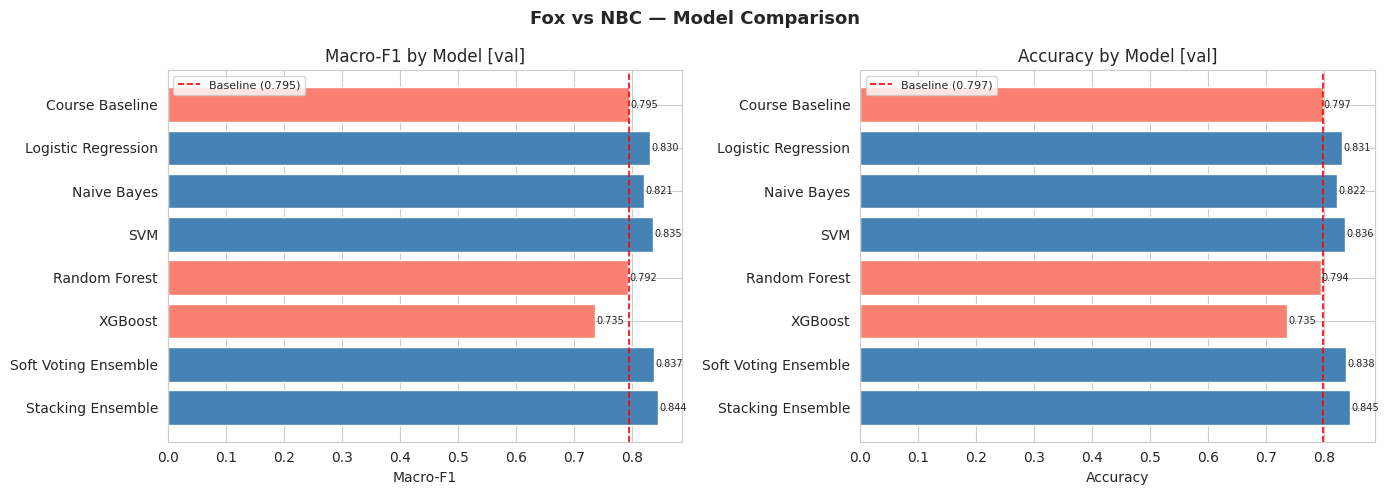

Saved to figures/model_progression.png — use this in your report.


In [28]:
val_results = [r for r in results if r["split"] == "val"]
chart_df = pd.DataFrame(val_results).drop_duplicates("model")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in [
        (axes[0], "macro_f1", "Macro-F1"),
        (axes[1], "accuracy", "Accuracy"),
]:
    colors = ["steelblue" if v > chart_df[metric].iloc[0] else "salmon"
              for v in chart_df[metric]]
    bars = ax.barh(chart_df["model"][::-1], chart_df[metric][::-1], color=colors[::-1])
    ax.axvline(chart_df[metric].iloc[0], color="red", linestyle="--",
               linewidth=1.2, label=f"Baseline ({chart_df[metric].iloc[0]:.3f})")
    ax.set_xlabel(label)
    ax.set_title(f"{label} by Model [val]")
    ax.legend(fontsize=8)
    for bar, val in zip(bars, chart_df[metric][::-1]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=7)

plt.suptitle("Fox vs NBC — Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_progression.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to figures/model_progression.png — use this in your report.")


## 17c. Leaderboard Submission

Generates `submission.csv` from the best model on the held-out **test set**.
Upload to the course leaderboard.


In [29]:
# Set to the test column matching your chosen best_model:
#   lr_X_test, svm_X_test, nb_X_test, rf_X_test, or xgb_X_test
_sub_X = lr_X_test

submission_preds = best_model.predict(_sub_X)

submission_df = pd.DataFrame({
    'id':     range(len(_sub_X)),
    'headline': _sub_X.values,
    'label':  submission_preds,          # 0 = NBC, 1 = FoxNews
    'source': ['FoxNews' if p == 1 else 'NBC' for p in submission_preds],
})

submission_path = PROJECT_ROOT / 'submission.csv'
submission_df.to_csv(submission_path, index=False)
print(f'Saved {len(submission_df)} predictions → {submission_path}')
print(submission_df.head())
print(f'\nFox: {(submission_preds==1).sum()} | NBC: {(submission_preds==0).sum()}')


NameError: name 'best_model' is not defined

## 18. Final Evaluation on Test Set

Run **once only**, after model selection on val is complete.
Set `best_model` and `best_X_test` to whichever model won.


In [ ]:
# Choose the best model from val results and set the matching test column:
#   improved_lr / lr_X_test
#   svm         / svm_X_test
#   nb          / nb_X_test
#   rf          / rf_X_test
#   xgb_model   / xgb_X_test
best_model  = improved_lr
best_name   = 'Logistic Regression'
best_X_test = lr_X_test

evaluate(best_name, best_model, best_X_test, y_test, split='test')


## 19. Save Best Model


In [ ]:
model_path = MODEL_DIR / 'best_model.joblib'
joblib.dump(best_model, model_path)
print(f'Saved to {model_path}')

loaded  = joblib.load(model_path)
samples = X_val.iloc[:3].tolist()
preds   = loaded.predict(samples)
for s, p in zip(samples, preds):
    label = 'FoxNews' if p == 1 else 'NBC'
    print(f'  [{label}]  {s[:80]}')

## 20. Retrain on Train + Val

Once the best model is confirmed, retrain on the full train+val set (~15% more data)
before final submission.


In [ ]:
# Use the same text column as best_model.
# Update best_X_train/best_X_val to match whichever model won on val.
best_X_train = lr_X_train   # e.g. svm_X_train, nb_X_train, rf_X_train, xgb_X_train
best_X_val   = lr_X_val

X_tv = pd.concat([best_X_train, best_X_val]).reset_index(drop=True)
y_tv = pd.concat([y_train, y_val]).reset_index(drop=True)

best_model.fit(X_tv, y_tv)
print(f'Retrained on {len(X_tv)} examples (train + val).')

final_path = MODEL_DIR / 'final_model.joblib'
joblib.dump(best_model, final_path)
print(f'Saved → {final_path}')
